In [42]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Enable Inline Plotting in Notebook
%matplotlib inline



Available DP tags: ['dp_eps1p0_delta1e-05_max1p0_noise0p1', 'dp_eps1p0_delta1e-05_max1p0_noise0p2', 'dp_eps1p0_delta1e-05_max1p0_noise0p5']
Using DP tag: dp_eps1p0_delta1e-05_max1p0_noise0p5


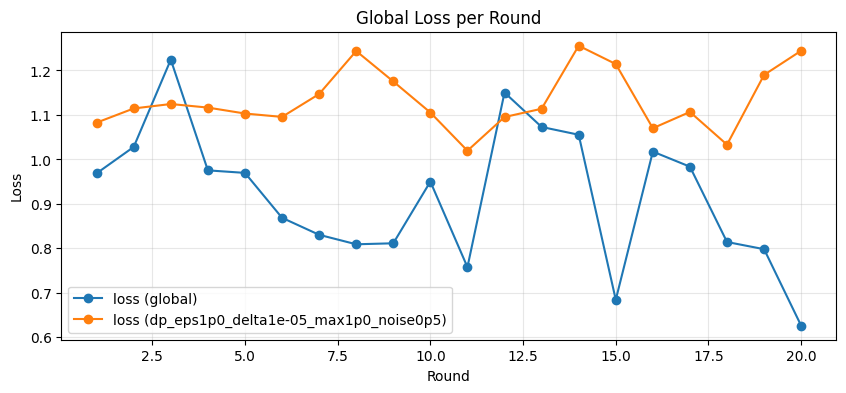

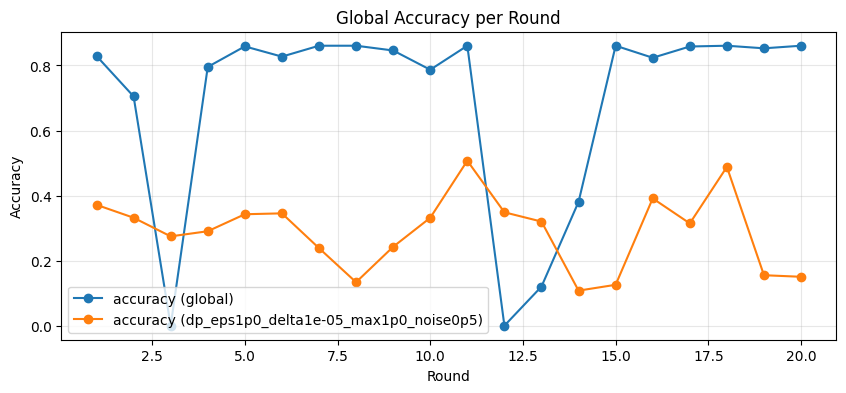

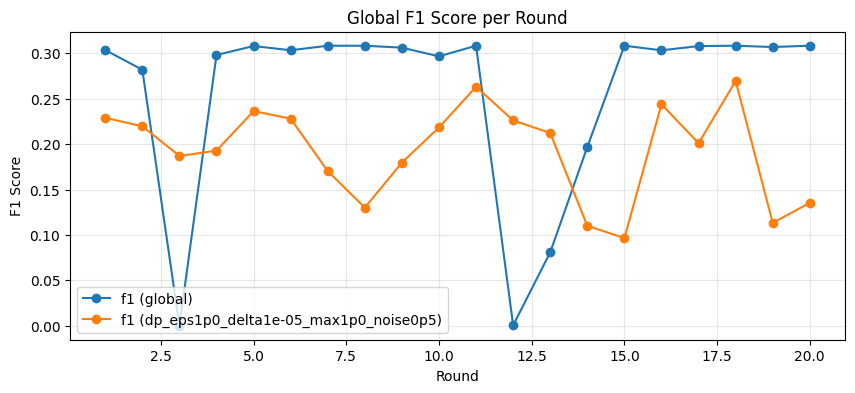

In [10]:
# Load and Plot VFL Metrics (global + client, including DP)

# Change this path if your logs are stored elsewhere.
logs_dir = Path("logs")

# Helper to load metrics (returns None if missing)
def load_csv(path: Path):
    if path.exists():
        return pd.read_csv(path)
    return None

# Detect DP tags from saved metric filenames
# Example: metrics_global_dp_eps1p0_delta1e-05_max1p0_noise0p1.csv
def list_dp_tags(logs_dir: Path):
    tags = []
    for p in logs_dir.glob("metrics_global_dp_*.csv"):
        stem = p.stem
        # stem = 'metrics_global_dp_eps1p0_delta1e-05_max1p0_noise0p1'
        tag = stem.replace("metrics_global_", "")
        tags.append(tag)
    return sorted(tags)

# Choose a DP tag (None = no DP logs will be loaded)
# If you have multiple tags, you can set `dp_tag` manually (e.g., "dp_eps1p0_delta1e-05_max1p0_noise0p1").
# Otherwise, the latest tag found will be used automatically.
available_dp_tags = list_dp_tags(logs_dir)
dp_tag = available_dp_tags[-1] if available_dp_tags else None

print("Available DP tags:", available_dp_tags)
print("Using DP tag:", dp_tag)

# Load global metrics
metrics_global = load_csv(logs_dir / "metrics_global.csv")

# Load all DP metrics for each tag
metrics_global_dp_by_tag = {
    tag: load_csv(logs_dir / f"metrics_global_{tag}.csv") for tag in available_dp_tags
}
metrics_clients_dp_by_tag = {
    tag: load_csv(logs_dir / f"metrics_clients_{tag}.csv") for tag in available_dp_tags
}

# Shortcut variables for the currently selected tag
metrics_global_dp = metrics_global_dp_by_tag.get(dp_tag)
metrics_clients_dp = metrics_clients_dp_by_tag.get(dp_tag)

# Load client metrics
metrics_clients = load_csv(logs_dir / "metrics_clients.csv")


# Plot global metrics (loss + accuracy + F1)
if metrics_global is not None or any(metrics_global_dp_by_tag.values()):
    plt.figure(figsize=(10, 4))
    if metrics_global is not None:
        plt.plot(metrics_global["round"], metrics_global["loss"], marker="o", label="loss (global)")
    for tag, df in metrics_global_dp_by_tag.items():
        if df is None:
            continue
        plt.plot(df["round"], df["loss"], marker="o", label=f"loss ({tag})")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.title("Global Loss per Round")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if (metrics_global is not None and "accuracy" in metrics_global.columns) or any(
        df is not None and "accuracy" in df.columns for df in metrics_global_dp_by_tag.values()
    ):
        plt.figure(figsize=(10, 4))
        if metrics_global is not None and "accuracy" in metrics_global.columns:
            plt.plot(metrics_global["round"], metrics_global["accuracy"], marker="o", label="accuracy (global)")
        for tag, df in metrics_global_dp_by_tag.items():
            if df is None or "accuracy" not in df.columns:
                continue
            plt.plot(df["round"], df["accuracy"], marker="o", label=f"accuracy ({tag})")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.title("Global Accuracy per Round")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    # Plot F1 score if present
    if (metrics_global is not None and "f1" in metrics_global.columns) or any(
        df is not None and "f1" in df.columns for df in metrics_global_dp_by_tag.values()
    ):
        plt.figure(figsize=(10, 4))
        if metrics_global is not None and "f1" in metrics_global.columns:
            plt.plot(metrics_global["round"], metrics_global["f1"], marker="o", label="f1 (global)")
        for tag, df in metrics_global_dp_by_tag.items():
            if df is None or "f1" not in df.columns:
                continue
            plt.plot(df["round"], df["f1"], marker="o", label=f"f1 ({tag})")
        plt.xlabel("Round")
        plt.ylabel("F1 Score")
        plt.title("Global F1 Score per Round")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


In [21]:
# Quick diagnostics: display max F1 and last few rows for each DP tag

# Recompute DP tag list in case the kernel state changed
logs_dir = Path("logs")

def list_dp_tags(logs_dir: Path):
    tags = []
    for p in logs_dir.glob("metrics_global_dp_*.csv"):
        stem = p.stem
        tag = stem.replace("metrics_global_", "")
        tags.append(tag)
    return sorted(tags)

available_dp_tags = list_dp_tags(logs_dir)
metrics_global_dp_by_tag = {
    tag: pd.read_csv(logs_dir / f"metrics_global_{tag}.csv") for tag in available_dp_tags
}

for tag, df in metrics_global_dp_by_tag.items():
    print(f"\nTag: {tag} -> max F1 = {df['f1'].max():.4f}")
    display(df.tail(3))



Tag: dp_eps1p0_delta1e-05_max1p0_noise0p1 -> max F1 = 0.3084


,round,loss,accuracy,f1
17,18,0.969199,0.773459,0.295889
18,19,0.892714,0.860446,0.308335
19,20,1.162043,0.040066,0.029261



Tag: dp_eps1p0_delta1e-05_max1p0_noise0p2 -> max F1 = 0.3265


,round,loss,accuracy,f1
17,18,0.877604,0.853914,0.307195
18,19,0.869494,0.857490,0.307981
19,20,0.876957,0.857344,0.308979



Tag: dp_eps1p0_delta1e-05_max1p0_noise0p5 -> max F1 = 0.2696


,round,loss,accuracy,f1
17,18,1.033158,0.488182,0.269555
18,19,1.190060,0.155239,0.113279
19,20,1.244424,0.150430,0.135386


## Fairness metrics (EOD / SDP) by Sex

We compute **Equal Opportunity Difference (EOD)** and **Statistical Demographic Parity (SDP)** using the saved best models:

- Non-DP: `models/best_server_f1*.pt` and `models/best_client_*_f1*.pt`
- DP: `models/<dp_tag>/dp_best_server_f1_<dp_tag>.pt` and `models/<dp_tag>/dp_best_client_*_f1_<dp_tag>.pt`

Model loading

In [ ]:
import torch
from vfl_dp.dataset import load_dataset
from vfl_dp.split import vertical_split
from vfl.models import ClientModel as NonDpClientModel, ServerModel as NonDpServerModel
from vfl_dp.models import ClientModel as DpClientModel
from vfl_dp.server import ServerModel as DpServerModel

# ---------------------------------------------------------------------------
# Locate saved model checkpoints (non-DP and DP) and prepare model instances
# ---------------------------------------------------------------------------
models_root = Path("models")

# Load dataset (used by both non-DP and DP scripts)
raw_df = load_dataset()
data_dict, _ = vertical_split(raw_df)

EMB_DIM = 8
n_clients = len(data_dict)

# Build non-DP model instances (architecture must match training)
non_dp_server = NonDpServerModel(n_clients, EMB_DIM)
non_dp_clients = [
    NonDpClientModel(input_dim=data_dict[k].shape[1], emb_dim=EMB_DIM)
    for k in data_dict.keys()
]

# Helper to pick the latest matching checkpoint
def last_checkpoint(path: Path, pattern: str):
    if not path.exists():
        return None
    files = sorted(path.glob(pattern))
    return next(iter(files), None)

# Non-DP checkpoints (from run_experiment_vfl.py)
server_ckpt = last_checkpoint(models_root, "best_server_f1*.pt")
client_ckpts = sorted(models_root.glob("best_client_*_f1*.pt"))

# Load non-DP weights
if server_ckpt is not None:
    non_dp_server.load_state_dict(torch.load(server_ckpt))
for m, ckpt in zip(non_dp_clients, client_ckpts):
    m.load_state_dict(torch.load(ckpt))

# Load DP models for all tags (from run_experiment_vfl_dp.py)
dp_models = {}
for tag in available_dp_tags:
    dp_dir = models_root / tag
    dp_server_ckpt = last_checkpoint(dp_dir, "dp_best_server_f1*.pt")
    dp_client_ckpts = sorted(dp_dir.glob("dp_best_client_*_f1*.pt"))

    if dp_server_ckpt is None:
        continue

    dp_server_model = DpServerModel(n_clients, EMB_DIM)
    dp_server_model.load_state_dict(torch.load(dp_server_ckpt))

    client_keys = sorted(data_dict.keys())
    dp_client_models = []
    for k, ckpt in zip(client_keys, dp_client_ckpts):
        m = DpClientModel(input_dim=data_dict[k].shape[1], emb_dim=EMB_DIM)
        m.load_state_dict(torch.load(ckpt))
        dp_client_models.append(m)

    dp_models[tag] = {
        "server": dp_server_model,
        "clients": dp_client_models,
        "server_ckpt": dp_server_ckpt,
        "client_ckpts": dp_client_ckpts,
    }

# Default DP models (for the selected dp_tag)
dp_server = dp_models.get(dp_tag, {}).get("server")
dp_clients = dp_models.get(dp_tag, {}).get("clients", [])



Non-DP server checkpoint: models\best_server_f1.pt
Loaded 4 non-DP client checkpoints
Available DP tags loaded: ['dp_eps1p0_delta1e-05_max1p0_noise0p1', 'dp_eps1p0_delta1e-05_max1p0_noise0p2', 'dp_eps1p0_delta1e-05_max1p0_noise0p5']


Metrics computation

In [ ]:
# Main result object
dict_res = {}           

# Inspect how predictions map to true labels (confusion counts)
# This helps confirm whether the model is using an unexpected class (e.g. 2) while labels are only {0,1}.

def map_preds(preds, mapping):
    out = preds.copy()
    for src, dst in mapping.items():
        out[out == src] = dst
    return out


def compute_fairness_from_preds(preds, label, sex):
    is_female = sex == 0
    is_male = sex == 1

    def compute_rates(mask):
        y_true = label[mask]
        y_pred = preds[mask]
        tpr = ((y_pred == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum())
        ppr = (y_pred == 1).mean()
        return float(tpr), float(ppr)

    tpr_f, ppr_f = compute_rates(is_female)
    tpr_m, ppr_m = compute_rates(is_male)

    return {
        "EOD": tpr_f - tpr_m,
        "SDP": ppr_f - ppr_m,
        "TPR_female": tpr_f,
        "TPR_male": tpr_m,
        "PPR_female": ppr_f,
        "PPR_male": ppr_m,
    }


def inspect_preds(server_model, client_models, data_dict, label, sex, prefix):
    if server_model is None or len(client_models) == 0:
        print(f"{prefix} model(s) missing")
        return None

    # Compute embeddings for each client
    embeddings = [m(data_dict[k]).detach() for m, k in zip(client_models, data_dict.keys())]
    logits = server_model(torch.cat(embeddings, dim=1))
    preds = torch.argmax(logits, dim=1).numpy()

    # Inspect prediction distribution
    uniq, cnts = np.unique(preds, return_counts=True)
    # print(f"{prefix} preds unique: {dict(zip(uniq, cnts))}")

    # Confusion counts (assuming positive class == 1)
    def confusion_counts(y_true, y_pred, positive=1):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        tp = int(((y_true == positive) & (y_pred == positive)).sum())
        tn = int(((y_true != positive) & (y_pred != positive)).sum())
        fp = int(((y_true != positive) & (y_pred == positive)).sum())
        fn = int(((y_true == positive) & (y_pred != positive)).sum())
        return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}

    # Store results into a dict (will be returned)
    result = {}

    result["preds"] = preds
    result["confusion"] = confusion_counts(label, preds)
    result["fairness"] = compute_fairness_from_preds(preds, label, sex)


    # If class 2 is present, map 2 -> 1 and overwrite metrics (as requested)
    if 2 in preds:
        mapped = map_preds(preds, {2: 1})
        result["preds"] = mapped
        result["confusion"] = confusion_counts(label, mapped)
        result["fairness"] = compute_fairness_from_preds(mapped, label, sex)
    # print(f"{prefix} confusion -> {result['confusion']}")
    # print(f"{prefix} fairness -> {result['fairness']}")
    dict_res[prefix] = {}
    dict_res[prefix]["confusion"] = result['confusion']
    dict_res[prefix]["fairness"] = result['fairness']

    return result


non_dp_results = {"model": inspect_preds(non_dp_server, non_dp_clients, data_dict, label, sex, "non-DP")}

# Collect results for each DP tag
results_by_tag = {}
for tag, models in dp_models.items():
    results_by_tag[tag] = {"model": inspect_preds(
        models["server"], models["clients"], data_dict, label, sex, f"DP ({tag})"
    )}

# Shortcut for the currently selected tag
if dp_tag is not None:
    dp_results = results_by_tag.get(dp_tag, {}).get("model")
else:
    dp_results = None


### Metrics dataframe

In [40]:
import pandas as pd

data = {
    'non-DP': {
        'fairness': {'EOD': 0.08558596044774135, 'SDP': 0.05692224902715552, 'TPR_female': 0.20569224919884851, 'TPR_male': 0.12010628875110717, 'PPR_female': 0.13999746432445379, 'PPR_male': 0.08307521529729826}
    },
    'DP (dp_eps1p0_delta1e-05_max1p0_noise0p1)': {
        'fairness': {'EOD': 0.007675043499190487, 'SDP': 0.0050214910340356245, 'TPR_female': 0.16126228884905763, 'TPR_male': 0.15358724534986715, 'PPR_female': 0.08342372547086087, 'PPR_male': 0.07840223443682524}
    },
    'DP (dp_eps1p0_delta1e-05_max1p0_noise0p2)': {
        'fairness': {'EOD': 0.0, 'SDP': 0.0, 'TPR_female': 0.0, 'TPR_male': 0.0, 'PPR_female': 0.0, 'PPR_male': 0.0}
    },
    'DP (dp_eps1p0_delta1e-05_max1p0_noise0p5)': {
        'fairness': {'EOD': 0.028248554954173777, 'SDP': 0.08000451295233613, 'TPR_female': 0.913692900983108, 'TPR_male': 0.8854443460289342, 'PPR_female': 0.9095749926042797, 'PPR_male': 0.8295704796519435}
    }
}

# Création du DataFrame
fairness_df = pd.DataFrame.from_dict({k: v['fairness'] for k, v in data.items()}, orient='index')
fairness_df.index.name = 'Méthode'
fairness_df = fairness_df.reset_index()

# Display the results
fairness_df


,Méthode,EOD,SDP,TPR_female,TPR_male,PPR_female,PPR_male
0,non-DP,0.085586,0.056922,0.205692,0.120106,0.139997,0.083075
1,DP (dp_eps1p0_delta1e-05_max1p0_noise0p1),0.007675,0.005021,0.161262,0.153587,0.083424,0.078402
2,DP (dp_eps1p0_delta1e-05_max1p0_noise0p2),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,DP (dp_eps1p0_delta1e-05_max1p0_noise0p5),0.028249,0.080005,0.913693,0.885444,0.909575,0.829570


### Confusion matrix

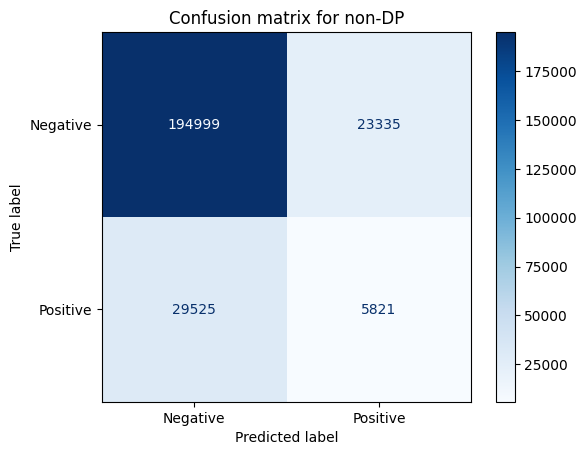

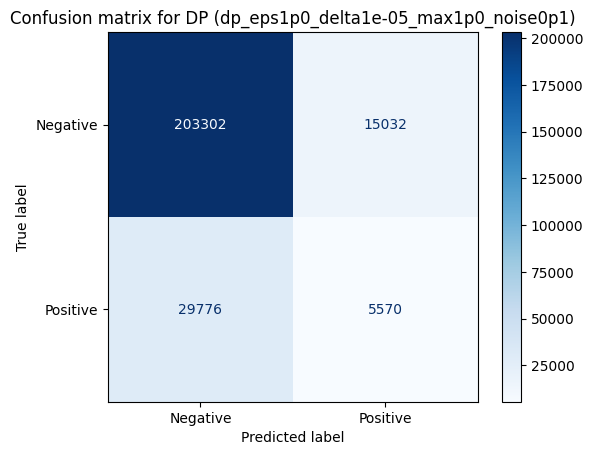

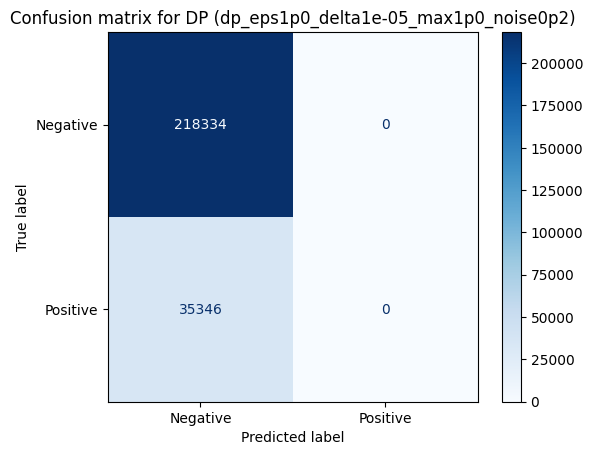

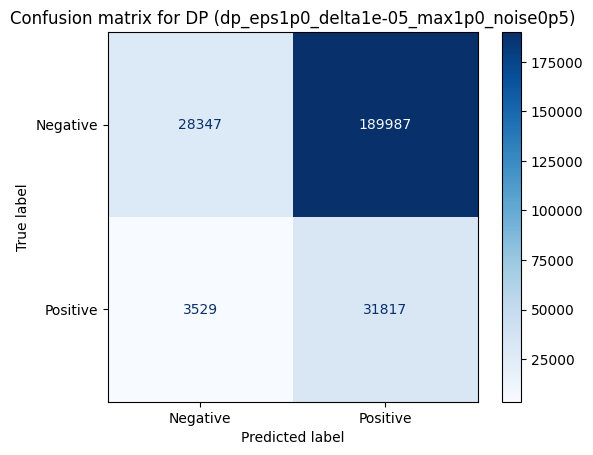

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

data = dict_res

for method, values in data.items():
    cm_data = values['confusion']
    # On construit la matrice de confusion dans l'ordre [[TN, FP], [FN, TP]]
    cm = np.array([[cm_data['TN'], cm_data['FP']], [cm_data['FN'], cm_data['TP']]])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion matrix for {method}")
    plt.show()
